In [1]:
import os
import subprocess 

import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
import scienceplots 
from astropy.cosmology import Planck18

plt.style.use("muted")

DATA_ROOT = os.getenv("DATA_ROOT")
latex_bin_path = f"/{DATA_ROOT}/texlive_store/texlive/bin/x86_64-linux"
os.environ["PATH"] = latex_bin_path + os.pathsep + os.environ["PATH"]

# 3. Verify which version is being picked up
try:
    version = subprocess.check_output(["latex", "--version"]).decode().splitlines()[0]
    print(f"Using LaTeX version: {version}")
except Exception as e:
    print(f"Error finding LaTeX: {e}")

# Now enable LaTeX rendering
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

Using LaTeX version: pdfTeX 3.141592653-2.6-1.40.28 (TeX Live 2025)


In [2]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import numpy as np

z_grid = np.linspace(0.001, 0.3, 300)

cosmo = FlatLambdaCDM(H0=100, Om0=0.3) # Cosmology used in the SDSS sample
D_L = cosmo.luminosity_distance(z_grid).to(u.pc)
d0 = 10. * u.pc
DM = 5 * np.log10(D_L/d0)
m_lim = 17.77
M_lim_curve = m_lim - DM

z_max_idx = 149 
M_lim_zmax = M_lim_curve[z_max_idx]

In [3]:
z_lims=["0.100", "0.105", "0.110", "0.115", "0.120", "0.125", "0.130", "0.135", "0.140", "0.145", "0.150"]
c = {"cond": "#0072B2", "uncond": "#CC79A7", "orig": "green"}
markers= {"cond": "o", "uncond": "s", "orig": "^"}
lbts = Planck18.lookback_time([float(z_lim) for z_lim in z_lims])

In [4]:
import numpy as np

# Prepare a dictionary to hold the final stacked arrays for each redshift
# Structure will be: results_by_z[z_lim]["cond"], etc.
results_by_z = {}

for z_lim in z_lims:
    # Lists to collect the specific rows across the 3 seeds for this redshift
    orig_seeds = []
    cond_seeds = []
    uncond_seeds = []
    
    for i in [0, 1, 2]:
        file_name = f"7655991_{i}_{float(z_lim):.3f}" 
        file_path = f"./mag_floor/{file_name}.npz"
        
        try:
            data = np.load(file_path)
            samples = data["samples"]
            orig_seeds.append(samples[0])  
            cond_seeds.append(samples[1])  
            uncond_seeds.append(samples[2]) 
            
        except FileNotFoundError:
            print(f"Cannot find {file_path}")
        except KeyError:
            print(f"'samples' key not found in {file_path}. Available keys: {data.files}")
            
    # Concatenate the lists of arrays across the seeds
    if orig_seeds:
        # np.concatenate(..., axis=0) chains the seed data together end-to-end
        results_by_z[z_lim] = {
            "orig": np.concatenate(orig_seeds, axis=0),
            "cond": np.concatenate(cond_seeds, axis=0),
            "uncond": np.concatenate(uncond_seeds, axis=0)
        }
    else:
        results_by_z[z_lim] = None
        print(f"No data loaded for z={z_lim}")

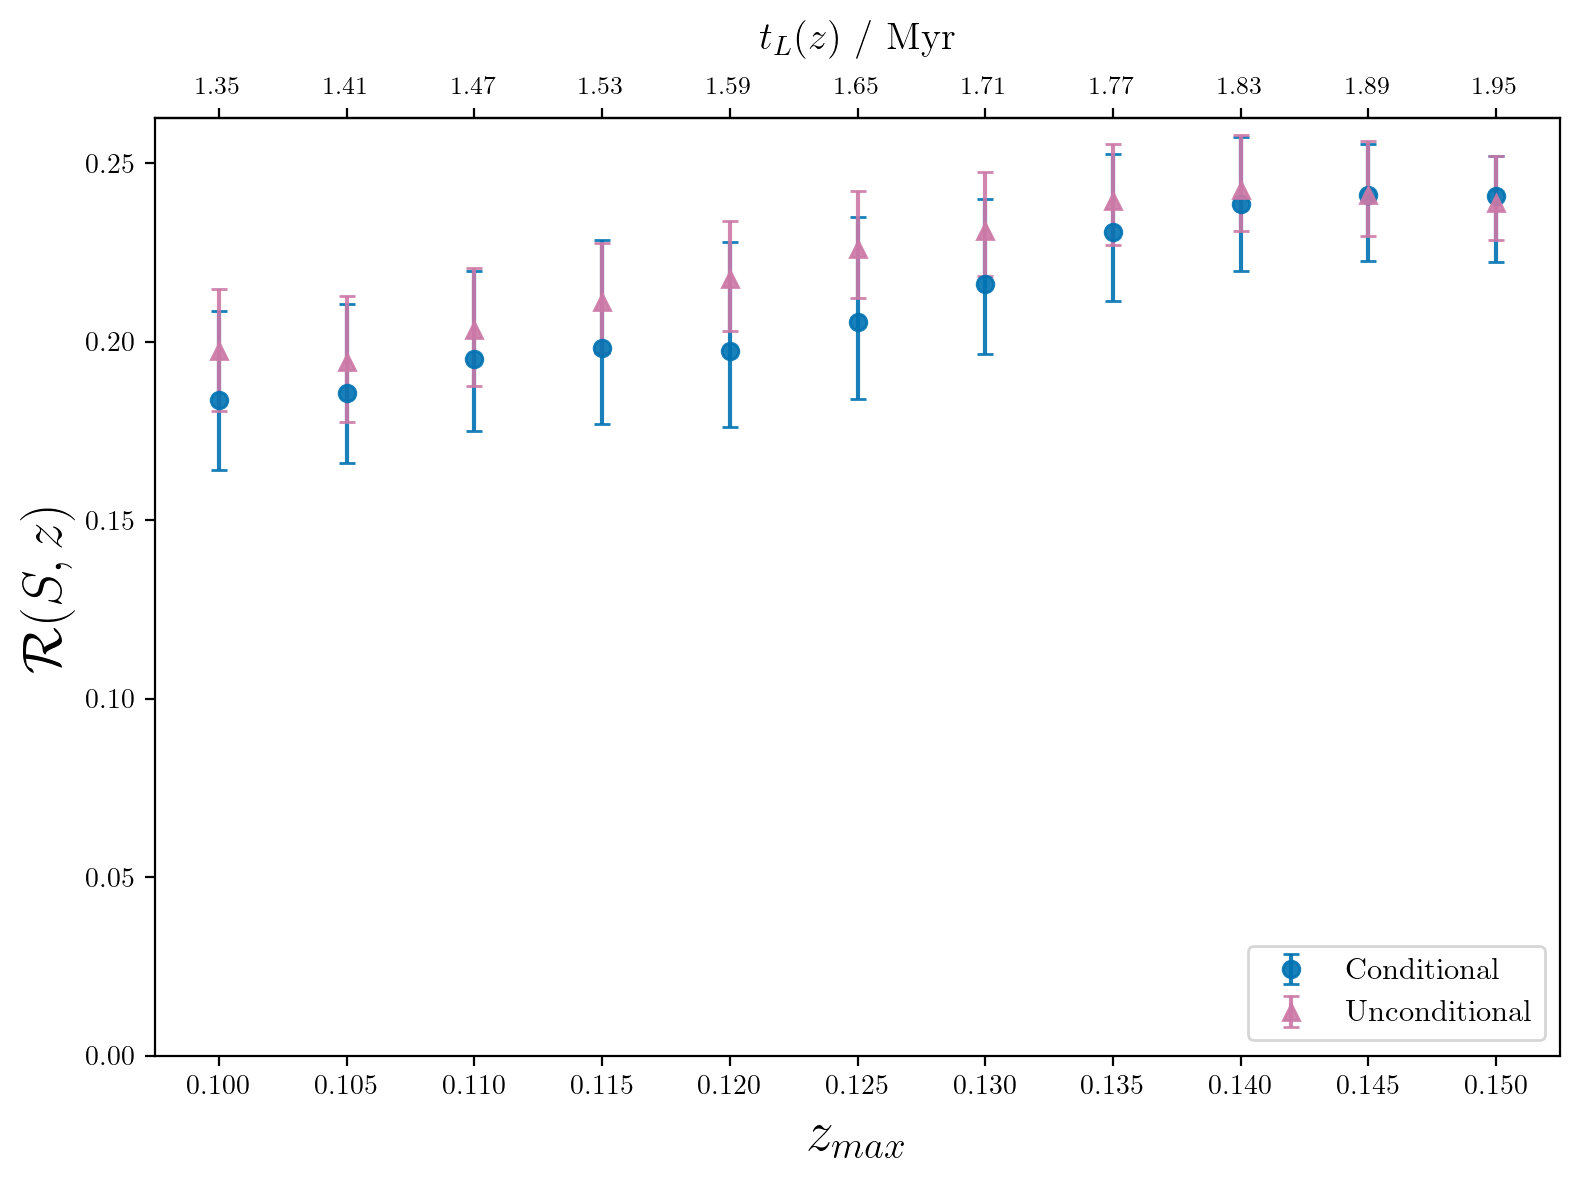

In [5]:
# --- prepare storage for plotting ---
z_vals = [float(z) for z in z_lims]

# Lists to store medians and asymmetric error bounds
med_cond, err_cond_lower, err_cond_upper = [], [], []
med_uncond, err_uncond_lower, err_uncond_upper = [], [], []

for z_lim in z_lims:
    cond_seeds = []
    uncond_seeds = []
    
    # 1. Load and stack the models for this specific redshift
    for i in [0, 1, 2]:
        file_name = f"7655991_{i}_{float(z_lim):.3f}" 
        file_path = f"./mag_floor/{file_name}.npz"
        try:
            data = np.load(file_path)
            samples = data["samples"]
            # Assuming row 1 is cond and row 2 is uncond (adjust if needed!)
            cond_seeds.append(samples[1])  
            uncond_seeds.append(samples[2])
        except Exception as e:
            print(f"Error with {file_path}: {e}")
            
    # 2. Concatenate the seeds
    if cond_seeds and uncond_seeds:
        stacked_cond = np.concatenate(cond_seeds, axis=0)
        stacked_uncond = np.concatenate(uncond_seeds, axis=0)
        
        # 3. Calculate Conditional Median & 95% CI (2.5th to 97.5th percentile)
        m_c = np.median(stacked_cond)
        p2_5_c = np.percentile(stacked_cond, 2.5)
        p97_5_c = np.percentile(stacked_cond, 97.5)
        med_cond.append(m_c)
        err_cond_lower.append(m_c - p2_5_c)    # Matplotlib errorbars require distance from median
        err_cond_upper.append(p97_5_c - m_c)
        
        # 4. Calculate Unconditional Median & 95% CI
        m_u = np.median(stacked_uncond)
        p2_5_u = np.percentile(stacked_uncond, 2.5)
        p97_5_u = np.percentile(stacked_uncond, 97.5)
        med_uncond.append(m_u)
        err_uncond_lower.append(m_u - p2_5_u)
        err_uncond_upper.append(p97_5_u - m_u)
        
    else:
        # Append NaNs if data is missing so arrays remain aligned
        for lst in (med_cond, err_cond_lower, err_cond_upper, med_uncond, err_uncond_lower, err_uncond_upper):
            lst.append(np.nan)

# Format for plt.errorbar (requires shape 2xN array for asymmetric errors)
err_cond = np.array([err_cond_lower, err_cond_upper])
err_uncond = np.array([err_uncond_lower, err_uncond_upper])

# Convert medians to arrays
med_cond = np.array(med_cond)
med_uncond = np.array(med_uncond)

# --- plotting: single panel ---
# Ensure your dictionary 'c' (for colors) and 'lbts' exist before this step!
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6), dpi=200)

# Plot against z_vals using median and 95% CI
ax1.errorbar(z_vals, med_cond, yerr=err_cond, fmt='o', color=c["cond"], alpha=0.9,
             label="Conditional", capsize=3)
ax1.errorbar(z_vals, med_uncond, yerr=err_uncond, fmt='^', color=c["uncond"], alpha=0.9,
             label="Unconditional", capsize=3)

# Main X and Y axis labels
ax1.set_xlabel(r"$z_{max}$", fontsize=20)
ax1.set_ylabel(r"$\mathcal{R}(S, z)$", fontsize=20)
ax1.legend(loc="lower right", fontsize=11)
ax1.set_ylim(0, None)
ax1.set_xticks(z_vals)

# --- ADD TOP X-AXIS ---
secax = ax1.secondary_xaxis('top')
secax.set_xlabel(r"$t_L(z)$ / Myr", fontsize=14, labelpad=10)
secax.set_xticks(z_vals)
secax.set_xticklabels([f"{lbt.value:.2f}" for lbt in lbts])

# Styling
ax1.tick_params(axis='both', which='major', labelsize=10)
secax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.show()